# Credit Card Fraud Detection - Neural Network Model
This notebook contains the implementation and evaluation of a Multilayer Perceptron (MLP) neural network. It explores algorithmic-level imbalance handling using custom Focal Loss, as well as a data-level comparison using SMOTE.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import random
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve, auc, f1_score, fbeta_score, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

sns.set_theme(style="whitegrid")

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using compute device: {device}")

Using compute device: mps


In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)

    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
df = pd.read_csv('creditcard.csv')

scaler = StandardScaler()
df['Scaled_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Scaled_Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

df.drop(['Time', 'Amount'], axis=1, inplace=True)
scaled_amount = df.pop('Scaled_Amount')
scaled_time = df.pop('Scaled_Time')
df.insert(0, 'Scaled_Time', scaled_time)
df.insert(1, 'Scaled_Amount', scaled_amount)

X = df.drop('Class', axis=1).values
y = df['Class'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1).to(device)

batch_size = 2048
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training tensors created. Shape: {X_train_tensor.shape}")
print(f"Test tensors created. Shape: {X_test_tensor.shape}")
print(f"Batches per epoch: {len(train_loader)}")

Training tensors created. Shape: torch.Size([227845, 30])
Test tensors created. Shape: torch.Size([56962, 30])
Batches per epoch: 112


In [4]:
class FraudMLP(nn.Module):
    def __init__(self, input_size):
        super(FraudMLP, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

In [5]:
print("Training Standard Neural Network on raw imbalanced data (Standard Binary Cross Entropy Loss)...")

set_seed(42)

criterion_bce = nn.BCEWithLogitsLoss()

input_dim = X_train_tensor.shape[1]
base_nn_model = FraudMLP(input_size=input_dim).to(device)
optimizer_base = optim.Adam(base_nn_model.parameters(), lr=0.001)

epochs = 20
base_nn_model.train()
for epoch in range(epochs):
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer_base.zero_grad()
        outputs = base_nn_model(batch_X)
        loss = criterion_bce(outputs, batch_y)
        loss.backward()
        optimizer_base.step()

base_nn_model.eval()
with torch.no_grad():
    base_nn_logits = base_nn_model(X_test_tensor.to(device))
    base_nn_probs = torch.sigmoid(base_nn_logits).cpu().numpy().squeeze()

y_test_numpy = np.array(y_test)

base_nn_precision, base_nn_recall, _ = precision_recall_curve(y_test_numpy, base_nn_probs)
base_nn_pr_auc = auc(base_nn_recall, base_nn_precision)

print(f"Base Neural Network (Standard BCE) PR-AUC: {base_nn_pr_auc:.4f}")

Training Standard Neural Network on raw imbalanced data (Standard Binary Cross Entropy Loss)...
Base Neural Network (Standard BCE) PR-AUC: 0.7958


Standard NN Confusion Matrix saved!


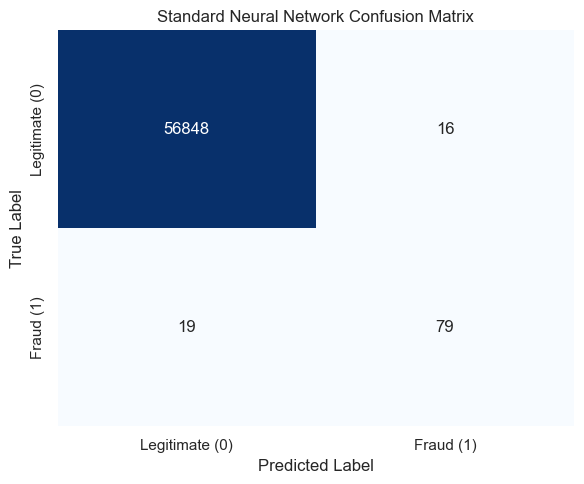

In [6]:
base_nn_preds = (base_nn_probs >= 0.50).astype(int)
cm_base_nn = confusion_matrix(y_test_numpy, base_nn_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_base_nn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legitimate (0)', 'Fraud (1)'], 
            yticklabels=['Legitimate (0)', 'Fraud (1)'])

plt.title('Standard Neural Network Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()

plt.savefig('nn_standard_neural_network_confusion_matrix.png', dpi=300)
print("Standard NN Confusion Matrix saved!")
plt.show()

In [7]:
print("Training custom Focal Loss Neural Network...")

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce_with_logits = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce_with_logits(inputs, targets)
        
        pt = torch.exp(-bce_loss) 
        focal_weight = self.alpha * (1 - pt)**self.gamma
        
        focal_loss = focal_weight * bce_loss
        return focal_loss.mean()

Training custom Focal Loss Neural Network...


In [8]:
input_dim = X_train_tensor.shape[1]

set_seed(42)

mlp_model = FraudMLP(input_size=input_dim).to(device)

criterion = FocalLoss(alpha=0.85, gamma=2.0)

learning_rate = 0.001
optimizer = optim.Adam(mlp_model.parameters(), lr=learning_rate)

print(mlp_model)
print(f"Model sent to: {device}")

FraudMLP(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
Model sent to: mps


In [9]:
epochs = 20

print("Starting training...")
for epoch in range(epochs):
    mlp_model.train()
    total_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = mlp_model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Average Focal Loss: {avg_loss:.4f}")

print("Training complete!")

Starting training...
Epoch [1/20] - Average Focal Loss: 0.0183
Epoch [5/20] - Average Focal Loss: 0.0010
Epoch [10/20] - Average Focal Loss: 0.0007
Epoch [15/20] - Average Focal Loss: 0.0007
Epoch [20/20] - Average Focal Loss: 0.0006
Training complete!


Neural Network PR-AUC: 0.8528
Default 0.5 Threshold F2-Score: 0.8350
Optimal Threshold: 0.4251 (Yields F2-Score: 0.8434)


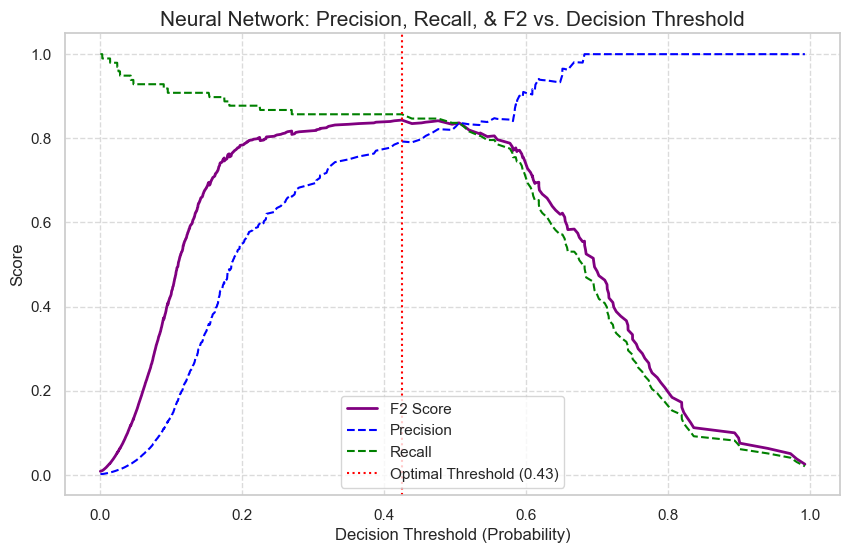

In [10]:
mlp_model.eval()

with torch.no_grad():
    test_logits = mlp_model(X_test_tensor)
    
    nn_probs = torch.sigmoid(test_logits).cpu().numpy().flatten()
    y_test_numpy = y_test_tensor.cpu().numpy().flatten()

nn_precision, nn_recall, nn_thresholds = precision_recall_curve(y_test_numpy, nn_probs)
nn_pr_auc = auc(nn_recall, nn_precision)
print(f"Neural Network PR-AUC: {nn_pr_auc:.4f}")

nn_f2_scores = (1 + 2**2) * (nn_precision[:-1] * nn_recall[:-1]) / ((2**2 * nn_precision[:-1]) + nn_recall[:-1] + 1e-8)

nn_optimal_idx = np.argmax(nn_f2_scores)
nn_optimal_threshold = nn_thresholds[nn_optimal_idx]
nn_best_f2 = nn_f2_scores[nn_optimal_idx]

nn_default_idx = np.searchsorted(nn_thresholds, 0.5)
nn_default_f2 = (1 + 2**2) * (nn_precision[nn_default_idx] * nn_recall[nn_default_idx]) / ((2**2 * nn_precision[nn_default_idx]) + nn_recall[nn_default_idx] + 1e-8)

print(f"Default 0.5 Threshold F2-Score: {nn_default_f2:.4f}")
print(f"Optimal Threshold: {nn_optimal_threshold:.4f} (Yields F2-Score: {nn_best_f2:.4f})")

plt.figure(figsize=(10, 6))
plt.plot(nn_thresholds, nn_f2_scores, label='F2 Score', color='purple', lw=2)
plt.plot(nn_thresholds, nn_precision[:-1], label='Precision', color='blue', linestyle='--')
plt.plot(nn_thresholds, nn_recall[:-1], label='Recall', color='green', linestyle='--')

plt.axvline(x=nn_optimal_threshold, color='red', linestyle=':', 
            label=f'Optimal Threshold ({nn_optimal_threshold:.2f})')

plt.title('Neural Network: Precision, Recall, & F2 vs. Decision Threshold', fontsize=15)
plt.xlabel('Decision Threshold (Probability)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(loc='lower center')
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig('nn_focal_loss_threshold_tuning.png', dpi=300, bbox_inches='tight')
plt.show()

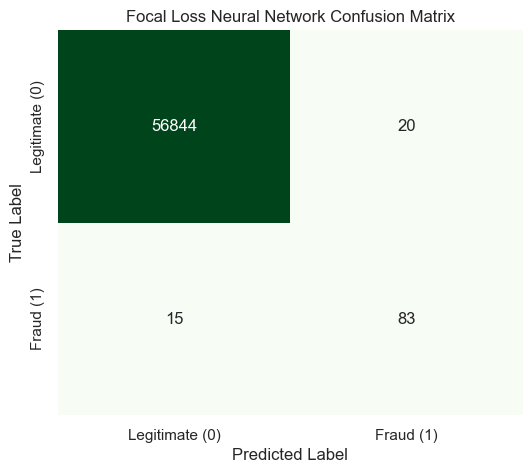

In [11]:
optimal_threshold_fl = 0.4553
nn_predictions = (nn_probs >= optimal_threshold_fl).astype(int)

cm_nn = confusion_matrix(y_test_numpy, nn_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Legitimate (0)', 'Fraud (1)'], yticklabels=['Legitimate (0)', 'Fraud (1)'])
plt.title('Focal Loss Neural Network Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('nn_focal_loss_neural_network_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
print("Generating SMOTE data for Neural Network...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

X_train_smote_tensor = torch.FloatTensor(X_train_smote).to(device)
y_train_smote_tensor = torch.FloatTensor(y_train_smote).view(-1, 1).to(device)

smote_train_dataset = TensorDataset(X_train_smote_tensor, y_train_smote_tensor)
smote_train_loader = DataLoader(smote_train_dataset, batch_size=batch_size, shuffle=True)

set_seed(42)

smote_mlp_model = FraudMLP(input_size=input_dim).to(device)
smote_criterion = nn.BCEWithLogitsLoss()
smote_optimizer = optim.Adam(smote_mlp_model.parameters(), lr=0.001)

epochs = 20
print("Starting SMOTE NN training...")
for epoch in range(epochs):
    smote_mlp_model.train()
    total_loss = 0
    
    for batch_X, batch_y in smote_train_loader:
        smote_optimizer.zero_grad()
        predictions = smote_mlp_model(batch_X)
        loss = smote_criterion(predictions, batch_y)
        loss.backward()
        smote_optimizer.step()
        total_loss += loss.item()
        
    avg_loss = total_loss / len(smote_train_loader)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Average BCE Loss: {avg_loss:.4f}")

print("SMOTE NN Training complete!")

Generating SMOTE data for Neural Network...
Starting SMOTE NN training...
Epoch [1/20] - Average BCE Loss: 0.1650
Epoch [5/20] - Average BCE Loss: 0.0139
Epoch [10/20] - Average BCE Loss: 0.0059
Epoch [15/20] - Average BCE Loss: 0.0037
Epoch [20/20] - Average BCE Loss: 0.0024
SMOTE NN Training complete!


In [13]:
smote_mlp_model.eval()

with torch.no_grad():
    smote_test_logits = smote_mlp_model(X_test_tensor)
    smote_nn_probs = torch.sigmoid(smote_test_logits).cpu().numpy().flatten()

smote_nn_precision, smote_nn_recall, smote_nn_thresholds = precision_recall_curve(y_test_numpy, smote_nn_probs)
smote_nn_pr_auc = auc(smote_nn_recall, smote_nn_precision)
print(f"SMOTE Neural Network PR-AUC: {smote_nn_pr_auc:.4f}")

smote_nn_f2_scores = (1 + 2**2) * (smote_nn_precision[:-1] * smote_nn_recall[:-1]) / ((2**2 * smote_nn_precision[:-1]) + smote_nn_recall[:-1] + 1e-8)

smote_nn_optimal_idx = np.argmax(smote_nn_f2_scores)
smote_nn_optimal_threshold = smote_nn_thresholds[smote_nn_optimal_idx]
smote_nn_best_f2 = smote_nn_f2_scores[smote_nn_optimal_idx]

smote_nn_default_idx = np.searchsorted(smote_nn_thresholds, 0.5)
smote_nn_default_f2 = (1 + 2**2) * (smote_nn_precision[smote_nn_default_idx] * smote_nn_recall[smote_nn_default_idx]) / ((2**2 * smote_nn_precision[smote_nn_default_idx]) + smote_nn_recall[smote_nn_default_idx] + 1e-8)

print(f"Default 0.5 Threshold F2-Score: {smote_nn_default_f2:.4f}")
print(f"Optimal Threshold: {smote_nn_optimal_threshold:.4f} (Yields F2-Score: {smote_nn_best_f2:.4f})")

SMOTE Neural Network PR-AUC: 0.8194
Default 0.5 Threshold F2-Score: 0.7782
Optimal Threshold: 0.9668 (Yields F2-Score: 0.8045)


SMOTE NN Confusion Matrix saved!


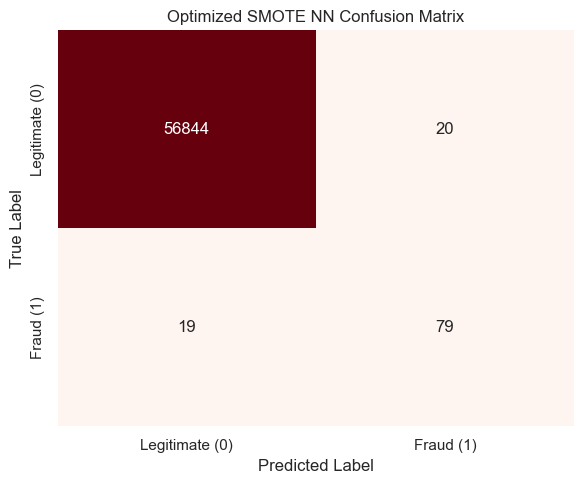

In [14]:
smote_mlp_model.eval()
with torch.no_grad():
    smote_nn_logits = smote_mlp_model(X_test_tensor.to(device))
    smote_nn_probs = torch.sigmoid(smote_nn_logits).cpu().numpy().squeeze()

prec_sm, rec_sm, thresh_sm = precision_recall_curve(y_test_numpy, smote_nn_probs)
f2_sm = (1 + 2**2) * (prec_sm[:-1] * rec_sm[:-1]) / ((2**2 * prec_sm[:-1]) + rec_sm[:-1] + 1e-8)
opt_idx_sm = np.argmax(f2_sm)
optimal_threshold_sm = thresh_sm[opt_idx_sm]

smote_nn_preds_opt = (smote_nn_probs >= optimal_threshold_sm).astype(int)

cm_smote_nn = confusion_matrix(y_test_numpy, smote_nn_preds_opt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_smote_nn, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Legitimate (0)', 'Fraud (1)'], 
            yticklabels=['Legitimate (0)', 'Fraud (1)'])

plt.title(f'Optimized SMOTE NN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()

plt.savefig('nn_smote_neural_network_confusion_matrix.png', dpi=300)
print("SMOTE NN Confusion Matrix saved!")
plt.show()

SMOTE NN Tuning Graph saved! (Optimal Threshold: 0.9668)


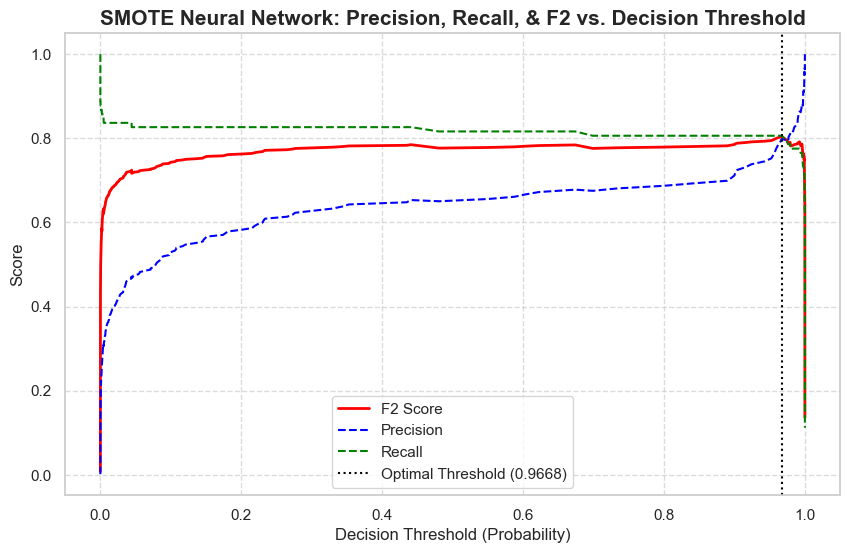

In [15]:
sm_precision, sm_recall, sm_thresholds = precision_recall_curve(y_test_numpy, smote_nn_probs)
sm_f2_scores = (1 + 2**2) * (sm_precision[:-1] * sm_recall[:-1]) / ((2**2 * sm_precision[:-1]) + sm_recall[:-1] + 1e-8)

sm_optimal_idx = np.argmax(sm_f2_scores)
sm_optimal_threshold = sm_thresholds[sm_optimal_idx]
sm_best_f2 = sm_f2_scores[sm_optimal_idx]

plt.figure(figsize=(10, 6))
plt.plot(sm_thresholds, sm_f2_scores, label='F2 Score', color='red', lw=2)
plt.plot(sm_thresholds, sm_precision[:-1], label='Precision', color='blue', linestyle='--')
plt.plot(sm_thresholds, sm_recall[:-1], label='Recall', color='green', linestyle='--')

plt.axvline(x=sm_optimal_threshold, color='black', linestyle=':', 
            label=f'Optimal Threshold ({sm_optimal_threshold:.4f})')

plt.title('SMOTE Neural Network: Precision, Recall, & F2 vs. Decision Threshold', fontsize=15, fontweight='bold')
plt.xlabel('Decision Threshold (Probability)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(loc='lower center')
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig('nn_smote_threshold_tuning.png', dpi=300, bbox_inches='tight')
print(f"SMOTE NN Tuning Graph saved! (Optimal Threshold: {sm_optimal_threshold:.4f})")
plt.show()

Master Neural Network PR-Curve generated and saved successfully!


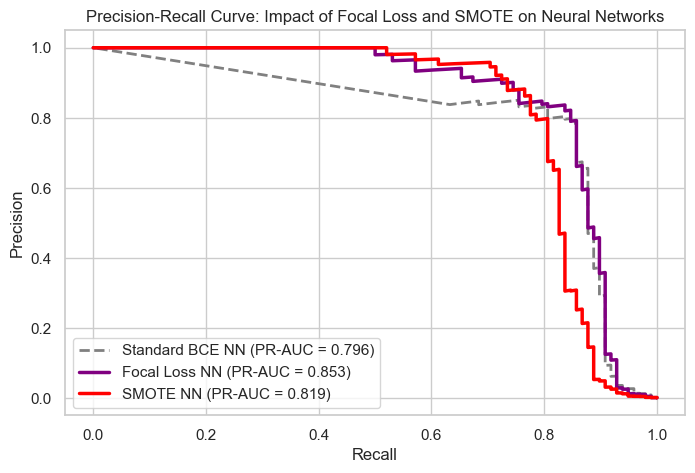

In [16]:
base_nn_precision, base_nn_recall, _ = precision_recall_curve(y_test_numpy, base_nn_probs)
fl_precision, fl_recall, _ = precision_recall_curve(y_test_numpy, nn_probs)
smote_nn_precision, smote_nn_recall, _ = precision_recall_curve(y_test_numpy, smote_nn_probs)

plt.figure(figsize=(8, 5))

plt.plot(base_nn_recall, base_nn_precision, label=f'Standard BCE NN (PR-AUC = {base_nn_pr_auc:.3f})', color='gray', linestyle='--', lw=2)

plt.plot(fl_recall, fl_precision, label=f'Focal Loss NN (PR-AUC = {auc(fl_recall, fl_precision):.3f})', color='purple', lw=2.5)
plt.plot(smote_nn_recall, smote_nn_precision, label=f'SMOTE NN (PR-AUC = {auc(smote_nn_recall, smote_nn_precision):.3f})', color='red', lw=2.5)

plt.title('Precision-Recall Curve: Impact of Focal Loss and SMOTE on Neural Networks')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')

plt.savefig('nn_neural_network_models_pr_curve.png', dpi=300, bbox_inches='tight')
print("Master Neural Network PR-Curve generated and saved successfully!")
plt.show()

Updated Master PR-Curve generated and saved successfully!


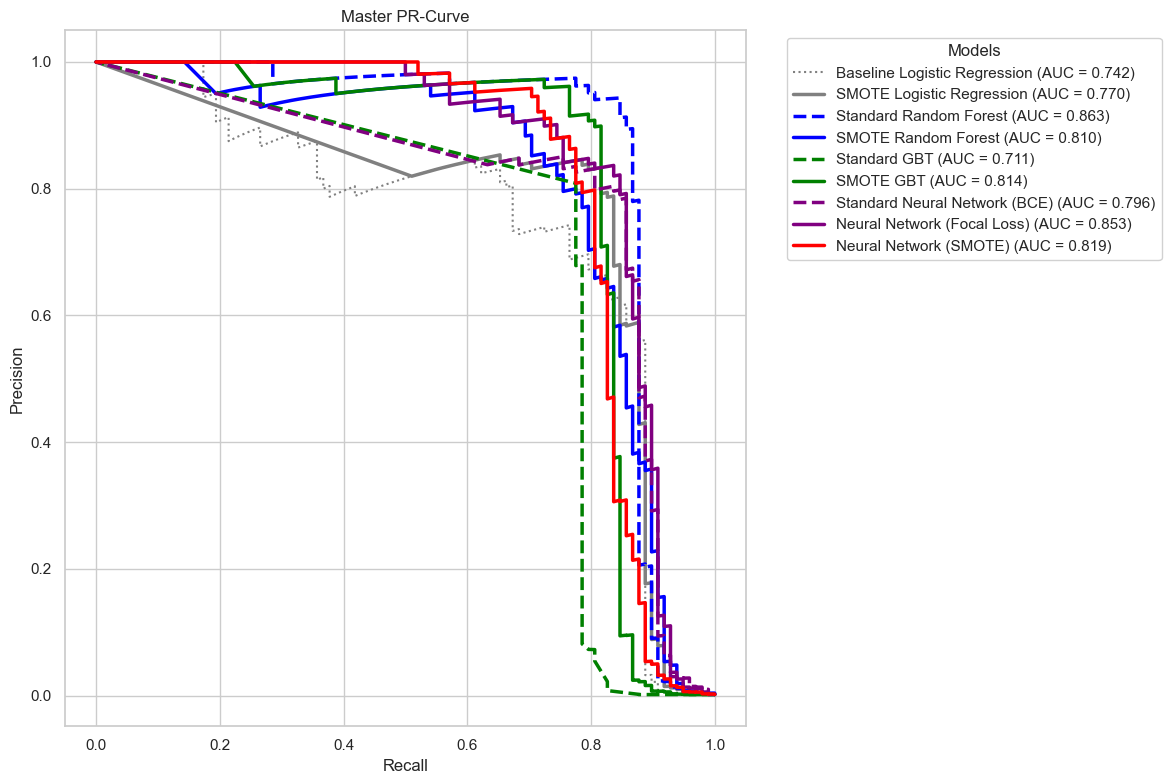

In [17]:
baseline_data = np.load('baseline_predictions.npz')
tree_data = np.load('tree_predictions.npz')

baseline_lr_probs = baseline_data['baseline_lr']
smote_lr_probs = tree_data['smote_lr']
rf_base_probs = tree_data['rf_base']
gbt_base_probs = tree_data['gbt_base']
rf_smote_probs = tree_data['rf']
gbt_smote_probs = tree_data['gbt']

models = {
    'Baseline Logistic Regression': baseline_lr_probs,
    'SMOTE Logistic Regression': smote_lr_probs,
    'Standard Random Forest': rf_base_probs,
    'SMOTE Random Forest': rf_smote_probs,
    'Standard GBT': gbt_base_probs,
    'SMOTE GBT': gbt_smote_probs,
    'Standard Neural Network (BCE)': base_nn_probs,
    'Neural Network (Focal Loss)': nn_probs,
    'Neural Network (SMOTE)': smote_nn_probs
}

plt.figure(figsize=(12, 8))

colors = ['gray', 'gray', 'blue', 'blue', 'green', 'green', 'purple', 'purple', 'red']
linestyles = [':', '-', '--', '-', '--', '-', '--', '-', '-']

for (name, probs), color, ls in zip(models.items(), colors, linestyles):
    precision, recall, _ = precision_recall_curve(y_test_numpy, probs)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{name} (AUC = {pr_auc:.3f})', color=color, linestyle=ls, lw=2.5 if '-' in ls else 1.5)

plt.title('Master PR-Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, framealpha=0.9, title="Models")

plt.tight_layout()
plt.savefig('master_pr_curve_updated.png', dpi=300, bbox_inches='tight')
print("Updated Master PR-Curve generated and saved successfully!")
plt.show()

In [18]:
base_nn_preds = (base_nn_probs >= 0.50).astype(int)
base_nn_prec_array, base_nn_rec_array, _ = precision_recall_curve(y_test_numpy, base_nn_probs)
base_nn_pr_auc = auc(base_nn_rec_array, base_nn_prec_array)
base_nn_cm = confusion_matrix(y_test_numpy, base_nn_preds)

print("--- STANDARD NEURAL NETWORK (BCE) ---")
print(f"Default Threshold: 0.5000")
print(f"PR-AUC:            {base_nn_pr_auc:.4f}")
print(f"F2-Score:          {fbeta_score(y_test_numpy, base_nn_preds, beta=2):.4f}")
print(f"Precision:         {precision_score(y_test_numpy, base_nn_preds):.4f}")
print(f"Recall:            {recall_score(y_test_numpy, base_nn_preds):.4f}")
print(f"True Positives:    {base_nn_cm[1, 1]} (Fraud)")
print(f"False Negatives:   {base_nn_cm[1, 0]} (Fraud but classified legit)")
print(f"False Positives:   {base_nn_cm[0, 1]} (Legit but classified fraud)")
print(f"True Negatives:    {base_nn_cm[0, 0]} (Legit)")
print("-------------------------------------\n")

--- STANDARD NEURAL NETWORK (BCE) ---
Default Threshold: 0.5000
PR-AUC:            0.7958
F2-Score:          0.8111
Precision:         0.8316
Recall:            0.8061
True Positives:    79 (Fraud)
False Negatives:   19 (Fraud but classified legit)
False Positives:   16 (Legit but classified fraud)
True Negatives:    56848 (Legit)
-------------------------------------



In [19]:
fl_prec_array, fl_rec_array, fl_thresh = precision_recall_curve(y_test_numpy, nn_probs)
fl_f2_scores = (1 + 2**2) * (fl_prec_array[:-1] * fl_rec_array[:-1]) / ((2**2 * fl_prec_array[:-1]) + fl_rec_array[:-1] + 1e-8)
fl_opt_idx = np.argmax(fl_f2_scores)
fl_opt_thresh = fl_thresh[fl_opt_idx]
fl_opt_preds = (nn_probs >= fl_opt_thresh).astype(int)
fl_cm = confusion_matrix(y_test_numpy, fl_opt_preds)

print("--- FOCAL LOSS NEURAL NETWORK (OPTIMIZED) ---")
print(f"Optimal Threshold: {fl_opt_thresh:.4f}")
print(f"PR-AUC:            {auc(fl_rec_array, fl_prec_array):.4f}")
print(f"F2-Score:          {fbeta_score(y_test_numpy, fl_opt_preds, beta=2):.4f}")
print(f"Precision:         {precision_score(y_test_numpy, fl_opt_preds):.4f}")
print(f"Recall:            {recall_score(y_test_numpy, fl_opt_preds):.4f}")
print(f"True Positives:    {fl_cm[1, 1]} (Fraud)")
print(f"False Negatives:   {fl_cm[1, 0]} (Fraud but classified legit)")
print(f"False Positives:   {fl_cm[0, 1]} (Legit but classified fraud)")
print(f"True Negatives:    {fl_cm[0, 0]} (Legit)")
print("---------------------------------------------\n")

--- FOCAL LOSS NEURAL NETWORK (OPTIMIZED) ---
Optimal Threshold: 0.4251
PR-AUC:            0.8528
F2-Score:          0.8434
Precision:         0.7925
Recall:            0.8571
True Positives:    84 (Fraud)
False Negatives:   14 (Fraud but classified legit)
False Positives:   22 (Legit but classified fraud)
True Negatives:    56842 (Legit)
---------------------------------------------



In [20]:
sm_prec_array, sm_rec_array, sm_thresh = precision_recall_curve(y_test_numpy, smote_nn_probs)
sm_f2_scores = (1 + 2**2) * (sm_prec_array[:-1] * sm_rec_array[:-1]) / ((2**2 * sm_prec_array[:-1]) + sm_rec_array[:-1] + 1e-8)
sm_opt_idx = np.argmax(sm_f2_scores)
sm_opt_thresh = sm_thresh[sm_opt_idx]
sm_opt_preds = (smote_nn_probs >= sm_opt_thresh).astype(int)
sm_cm = confusion_matrix(y_test_numpy, sm_opt_preds)

print("--- SMOTE NEURAL NETWORK (OPTIMIZED) ---")
print(f"Optimal Threshold: {sm_opt_thresh:.4f}")
print(f"PR-AUC:            {auc(sm_rec_array, sm_prec_array):.4f}")
print(f"F2-Score:          {fbeta_score(y_test_numpy, sm_opt_preds, beta=2):.4f}")
print(f"Precision:         {precision_score(y_test_numpy, sm_opt_preds):.4f}")
print(f"Recall:            {recall_score(y_test_numpy, sm_opt_preds):.4f}")
print(f"True Positives:    {sm_cm[1, 1]} (Fraud)")
print(f"False Negatives:   {sm_cm[1, 0]} (Fraud but classified legit)")
print(f"False Positives:   {sm_cm[0, 1]} (Legit but classified fraud)")
print(f"True Negatives:    {sm_cm[0, 0]} (Legit)")
print("----------------------------------------")

--- SMOTE NEURAL NETWORK (OPTIMIZED) ---
Optimal Threshold: 0.9668
PR-AUC:            0.8194
F2-Score:          0.8045
Precision:         0.7980
Recall:            0.8061
True Positives:    79 (Fraud)
False Negatives:   19 (Fraud but classified legit)
False Positives:   20 (Legit but classified fraud)
True Negatives:    56844 (Legit)
----------------------------------------
